In [1]:
import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_1ccee062f80d74be3a662b8daa6ddb2a"

In [2]:
!kaggle datasets download -d shreyamishra0307/realvsfake
!unzip -q realvsfake.zip

Dataset URL: https://www.kaggle.com/datasets/shreyamishra0307/realvsfake
License(s): MIT
100% 7.93G/7.93G [01:31<00:00, 93.2MB/s]



In [3]:
!mv whole/val/valid_fake whole/val/fake
!mv whole/val/valid_real whole/val/real
!mv whole/test/test_fake whole/test/fake
!mv whole/test/test_real whole/test/real
#zmiana nazw plików pod biblioteke

In [4]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Wczytywanie zbioru treningowego
train_dataset = tf.keras.utils.image_dataset_from_directory(
    'whole/train',
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# Wczytywanie zbioru walidacyjnego
val_dataset = tf.keras.utils.image_dataset_from_directory(
    'whole/val',
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# Optymalizacja ładowania danych (żeby karta graficzna nie czekała na dysk)
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

Found 6347 files belonging to 2 classes.
Found 643 files belonging to 2 classes.


In [5]:
# 1. Pobieramy ResNet50
base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# 2. Zamrażamy wagi bazowe
base_model.trainable = False

# 3. Budujemy naszą sieć
inputs = tf.keras.Input(shape=(224, 224, 3))

# Ważne: Zmieniamy preprocessing na ten dedykowany dla ResNet50!
x = tf.keras.applications.resnet50.preprocess_input(inputs)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)

# Warstwa wyjściowa
#tu jest 1 neuron wyjsciowy, czyli detekcja
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)

# 4. Kompilacja
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [6]:
# Trenujemy sieć. Na początek ustawiamy 3 epoki (przejścia przez całe dane).
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3
)

Epoch 1/3
199/199 ━━━━━━━━━━━━━━━━━━━━ 195s 897ms/step - accuracy: 0.9036 - loss: 0.2414 - val_accuracy: 0.6439 - val_loss: 1.0561
Epoch 2/3
199/199 ━━━━━━━━━━━━━━━━━━━━ 184s 854ms/step - accuracy: 0.9450 - loss: 0.1439 - val_accuracy: 0.6485 - val_loss: 1.1006
Epoch 3/3
199/199 ━━━━━━━━━━━━━━━━━━━━ 170s 852ms/step - accuracy: 0.9576 - loss: 0.1218 - val_accuracy: 0.6485 - val_loss: 1.1170


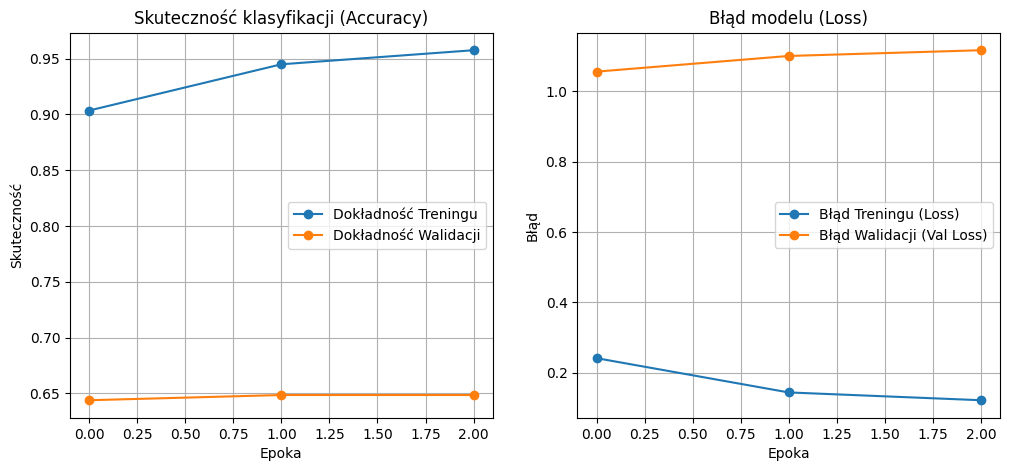

In [7]:
import matplotlib.pyplot as plt

# Ustawiamy rozmiar obrazka
plt.figure(figsize=(12, 5))

# --- WYKRES 1: Dokładność (Accuracy) ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Dokładność Treningu', marker='o')
plt.plot(history.history['val_accuracy'], label='Dokładność Walidacji', marker='o')
plt.title('Skuteczność klasyfikacji (Accuracy)')
plt.xlabel('Epoka')
plt.ylabel('Skuteczność')
plt.legend()
plt.grid(True)

# --- WYKRES 2: Błąd/Strata (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Błąd Treningu (Loss)', marker='o')
plt.plot(history.history['val_loss'], label='Błąd Walidacji (Val Loss)', marker='o')
plt.title('Błąd modelu (Loss)')
plt.xlabel('Epoka')
plt.ylabel('Błąd')
plt.legend()
plt.grid(True)

# Wyświetlenie wykresów
plt.show()

In [9]:
from google.colab import files

# 1. Zapisanie modelu do pliku .keras (w chmurze)
nazwa_pliku = 'detektor_deepfake_resnet.keras'
model.save(nazwa_pliku)

print("Model zapisany.")

# 2. Wywołanie pobierania pliku
files.download(nazwa_pliku)

Model zapisany.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#DO TESTOWANIA GOTOWEJ SIECI
import tensorflow as tf
import numpy as np

# Wczytujemy gotową, wytrenowaną sieć (trwa to sekundę)
moj_model = tf.keras.models.load_model('detektor_deepfake_resnet.keras')

# Funkcja do testowania własnych
def sprawdz_zdjecie(sciezka_do_zdjecia):
    img = tf.keras.utils.load_img(sciezka_do_zdjecia, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Dodanie wymiaru "batch"

    # Preprocessing dla ResNet50
    img_array = tf.keras.applications.resnet50.preprocess_input(img_array)

    wynik = moj_model.predict(img_array)[0][0]

    if wynik > 0.5:
        print(f"To zdjęcie jest PRAWDZIWE (pewność: {wynik * 100:.2f}%)")
    else:
        print(f"To zdjęcie jest FAKE (pewność: {(1 - wynik) * 100:.2f}%)")

